In [ ]:
import cv2
import numpy as np
from google.colab import files

class VibrantHDR:
    def __init__(self, key_value=0.12, saturation_power=1.2):
        self.key_value = key_value
        self.saturation_power = saturation_power

    def _compute_weights_strict(self, image):
        z = np.arange(256, dtype=np.float32)
        weights = np.minimum(z, 255 - z)
        # Kill clipped pixels
        weights[z >= 250] = 0.0
        weights[z <= 5] = 0.0
        return cv2.LUT(image, weights)

    def process(self, images, exposure_times):
        """
        Main pipeline: Radiance Map -> Tone Map -> Contrast -> Saturation
        """
        # 1. Construct Radiance Map
        radiance_sum = np.zeros_like(images[0], dtype=np.float32)
        weight_sum = np.zeros_like(images[0], dtype=np.float32)

        for img, time in zip(images, exposure_times):
            w = self._compute_weights_strict(img)
            img_float = img.astype(np.float32) / 255.0
            img_linear = np.power(img_float, 2.2) * 255.0
            radiance = img_linear / time
            radiance_sum += w * radiance
            weight_sum += w

        hdr_radiance = radiance_sum / np.maximum(weight_sum, 1e-8)

        # 2. Tone Mapping
        ldr = self._tone_map(hdr_radiance)

        # 3. Post-Processing
        contrasted = self._apply_s_curve(ldr)
        final = self._boost_saturation(contrasted, factor=1.4)

        return final

    def _tone_map(self, hdr_image):
        L_in = (0.114 * hdr_image[:, :, 0] +
                0.587 * hdr_image[:, :, 1] +
                0.299 * hdr_image[:, :, 2])
        L_in_safe = np.maximum(L_in, 1e-8)

        lum_log_avg = np.exp(np.mean(np.log(L_in_safe)))
        L_scaled = (self.key_value / lum_log_avg) * L_in
        L_out = L_scaled / (1.0 + L_scaled)

        mapped = np.zeros_like(hdr_image)
        for c in range(3):
            color_ratio = hdr_image[:, :, c] / L_in_safe
            color_ratio = np.power(color_ratio, self.saturation_power)
            mapped[:, :, c] = L_out * color_ratio

        mapped = np.power(np.clip(mapped, 0.0, 1.0), 1.0 / 2.2)
        return (mapped * 255).astype(np.uint8)

    def _apply_s_curve(self, image):
        img_float = image.astype(np.float32) / 255.0
        s_curve = 0.5 * (np.sin(np.pi * (img_float - 0.5)) + 1)
        blended = (0.6 * s_curve) + (0.4 * img_float)
        return np.clip(blended * 255.0, 0, 255).astype(np.uint8)

    def _boost_saturation(self, image, factor=1.3):
        hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV).astype(np.float32)
        hsv[:, :, 1] = np.clip(hsv[:, :, 1] * factor, 0, 255)
        return cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)

In [ ]:
hdr_tool = VibrantHDR()
processed_images = []
labels = ["DARK (Under-exposed)", "NORMAL (Balanced)", "BRIGHT (Over-exposed)"]

for label in labels:
    print(f"\n[STEP] Please upload the {label} image:")
    uploaded = files.upload()

    # Get the first (and only) file from this specific upload
    fname = list(uploaded.keys())[0]
    img = cv2.imread(fname)
    processed_images.append(img)
    print(f"Captured {fname} for {label} channel.")

# Define exposure times
exposure_times = np.array([0.8, 2.5, 6.0], dtype=np.float32)

print("\n--- Processing HDR ---")
final_image = hdr_tool.process(processed_images, exposure_times)
cv2.imwrite('vibrant_hdr_result.jpg', final_image)
print("Success! Download 'vibrant_hdr_result.jpg' from your files tab.")


[STEP] Please upload the DARK (Under-exposed) image:


Saving 1.jpg to 1 (1).jpg
Captured 1 (1).jpg for DARK (Under-exposed) channel.

[STEP] Please upload the NORMAL (Balanced) image:


Saving 2.jpg to 2 (1).jpg
Captured 2 (1).jpg for NORMAL (Balanced) channel.

[STEP] Please upload the BRIGHT (Over-exposed) image:


Saving 3.jpg to 3 (1).jpg
Captured 3 (1).jpg for BRIGHT (Over-exposed) channel.

--- Processing HDR ---
Success! Download 'vibrant_hdr_result.jpg' from your files tab.


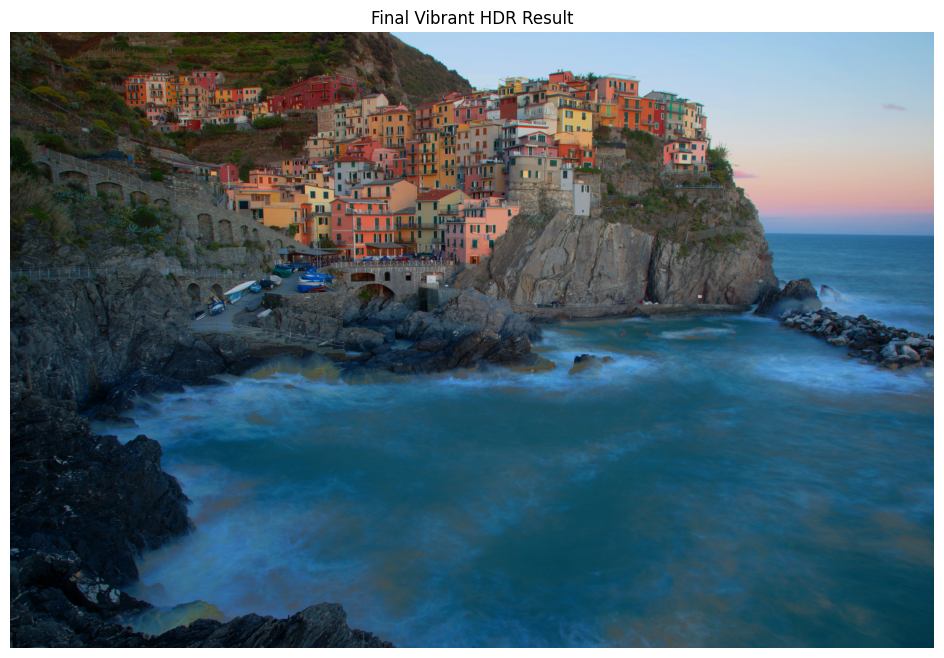

In [ ]:
import matplotlib.pyplot as plt

# 1. Convert BGR (OpenCV format) to RGB (Display format)
final_rgb = cv2.cvtColor(final_image, cv2.COLOR_BGR2RGB)

# 2. Display using Matplotlib
plt.figure(figsize=(12, 8))
plt.imshow(final_rgb)
plt.axis('off')  # Hide the pixel rulers
plt.title("Final Vibrant HDR Result")
plt.show()